# Pertanyaan Bisnis

1. Produk apa yang memiliki jumlah penjualan tertinggi pada aplikasi SiDoku selama periode transaksi penjualan tahun 2016 berlangsung?

2. Bagaimana tren total revenue penjualan produk pada aplikasi SiDoku di setiap bulan selama periode transaksi tahun 2016 berlangsung?

3. Hari apa yang memiliki aktivitas transaksi penjualan tertinggi berdasarkan data transaksi pada aplikasi SiDoku selama tahun 2016?

4. Produk apa yang menghasilkan total revenue terbesar pada aplikasi SiDoku selama periode transaksi penjualan tahun 2016 berlangsung?

5. Bagaimana distribusi harga produk berdasarkan data transaksi penjualan pada aplikasi SiDoku selama periode tahun 2016 berlangsung?

6. Apakah transaksi pada hari kerja (weekday) lebih tinggi dibandingkan akhir pekan (weekend) berdasarkan data transaksi aplikasi SiDoku?

7. Kategori harga produk apa yang paling mendominasi transaksi penjualan pada aplikasi SiDoku?

## Import Semua Packages/Library yang Digunakan

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Gathering Data

In [10]:
sales = pd.read_csv('../data/sales.csv')

sales.head()

,InventoryId,Store,Brand,Description,Size,SalesQuantity,SalesDollars,SalesPrice,SalesDate,Volume,Classification,ExciseTax,VendorNumber,VendorName
0,18_FURNESS_14006,18,14006,Apothic Winemakers Red Blend,750mL,2,19.98,9.99,2016-01-01,750,2,0.22,3252,E & J GALLO WINERY
1,15_WANBORNE_3348,15,3348,Bombay Sapphire Gin,1.75L,2,59.98,29.99,2016-01-01,1750,1,3.67,480,BACARDI USA INC
2,31_HORNSEY_1233,31,1233,Jack Daniels No 7 Black,1.75L,2,78.40,39.20,2016-01-01,1750,1,3.67,1128,BROWN-FORMAN CORP
3,15_WANBORNE_2114,15,2114,Black Velvet Canadian Whisky,1.75L,3,38.97,12.99,2016-01-01,1750,1,5.51,1392,CONSTELLATION BRANDS INC
4,12_LEESIDE_8680,12,8680,Crown Royal,1.75L,1,38.99,38.99,2016-01-01,1750,1,1.84,3960,DIAGEO NORTH AMERICA INC


## Assessing Data

In [11]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66200 entries, 0 to 66199
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   InventoryId     66200 non-null  object 
 1   Store           66200 non-null  int64  
 2   Brand           66200 non-null  int64  
 3   Description     66200 non-null  object 
 4   Size            66200 non-null  object 
 5   SalesQuantity   66200 non-null  int64  
 6   SalesDollars    66200 non-null  float64
 7   SalesPrice      66200 non-null  float64
 8   SalesDate       66200 non-null  object 
 9   Volume          66200 non-null  int64  
 10  Classification  66200 non-null  int64  
 11  ExciseTax       66200 non-null  float64
 12  VendorNumber    66200 non-null  int64  
 13  VendorName      66200 non-null  object 
dtypes: float64(3), int64(6), object(5)
memory usage: 7.1+ MB


In [12]:
# cek missing value

sales.isna().sum()

InventoryId       0
Store             0
Brand             0
Description       0
Size              0
SalesQuantity     0
SalesDollars      0
SalesPrice        0
SalesDate         0
Volume            0
Classification    0
ExciseTax         0
VendorNumber      0
VendorName        0
dtype: int64

In [13]:
# statistik deskriptif
sales.describe()

,Store,Brand,SalesQuantity,SalesDollars,SalesPrice,Volume,Classification,ExciseTax,VendorNumber
count,66200.000000,66200.000000,66200.000000,66200.000000,66200.000000,66200.000000,66200.000000,66200.000000,66200.000000
mean,26.823988,4391.728625,3.943338,87.157168,23.455386,1447.330060,1.070710,5.888901,7046.435604
std,21.790693,2907.364526,5.472930,125.555698,8.909219,457.999976,0.256342,8.625744,5427.591485
min,1.000000,1232.000000,1.000000,9.330000,9.310000,750.000000,1.000000,0.110000,480.000000
25%,12.000000,2585.000000,1.000000,28.837500,17.270000,750.000000,1.000000,1.840000,3960.000000
50%,17.000000,3650.000000,2.000000,51.980000,22.510000,1750.000000,1.000000,3.670000,4425.000000
75%,41.000000,5138.000000,5.000000,100.965000,28.442500,1750.000000,1.000000,7.350000,12546.000000
max,79.000000,19748.000000,248.000000,5047.980000,62.320000,1750.000000,2.000000,371.170000,17035.000000


## Cleaning Data

In [14]:
# ubah format tanggal
sales['SalesDate'] = pd.to_datetime(sales['SalesDate'])

sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66200 entries, 0 to 66199
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   InventoryId     66200 non-null  object        
 1   Store           66200 non-null  int64         
 2   Brand           66200 non-null  int64         
 3   Description     66200 non-null  object        
 4   Size            66200 non-null  object        
 5   SalesQuantity   66200 non-null  int64         
 6   SalesDollars    66200 non-null  float64       
 7   SalesPrice      66200 non-null  float64       
 8   SalesDate       66200 non-null  datetime64[ns]
 9   Volume          66200 non-null  int64         
 10  Classification  66200 non-null  int64         
 11  ExciseTax       66200 non-null  float64       
 12  VendorNumber    66200 non-null  int64         
 13  VendorName      66200 non-null  object        
dtypes: datetime64[ns](1), float64(3), int64(6), object(4)


In [15]:
# drop column yang tidak digunakan
columns_to_drop = [
    'InventoryId',
    'Store',
    'ExciseTax',
    'Volume',
    'Classification',
    'SalesDollars',
    'VendorNumber',
    'VendorName'
]

sales.drop(columns=columns_to_drop, inplace=True)

sales.head()

,Brand,Description,Size,SalesQuantity,SalesPrice,SalesDate
0,14006,Apothic Winemakers Red Blend,750mL,2,9.99,2016-01-01
1,3348,Bombay Sapphire Gin,1.75L,2,29.99,2016-01-01
2,1233,Jack Daniels No 7 Black,1.75L,2,39.20,2016-01-01
3,2114,Black Velvet Canadian Whisky,1.75L,3,12.99,2016-01-01
4,8680,Crown Royal,1.75L,1,38.99,2016-01-01


In [16]:
sales.to_csv('../data/sales_clean.csv', index=False)

----------------- Exploratory Data Analysis (EDA) -----------------

## Univariate Analysis

In [17]:
sales.describe()

,Brand,SalesQuantity,SalesPrice,SalesDate
count,66200.000000,66200.000000,66200.000000,66200
mean,4391.728625,3.943338,23.455386,2016-06-29 17:17:10.187311104
min,1232.000000,1.000000,9.310000,2016-01-01 00:00:00
25%,2585.000000,1.000000,17.270000,2016-03-26 00:00:00
50%,3650.000000,2.000000,22.510000,2016-06-28 00:00:00
75%,5138.000000,5.000000,28.442500,2016-10-03 00:00:00
max,19748.000000,248.000000,62.320000,2016-12-28 00:00:00
std,2907.364526,5.472930,8.909219,NaN


### Insight

- Dataset penjualan memiliki 66.200 data transaksi selama periode tahun 2016 berlangsung.
- Rata-rata jumlah produk yang terjual pada setiap transaksi berada di kisaran 3 hingga 4 produk.
- Harga jual produk memiliki rata-rata sebesar 23 yang menunjukkan variasi harga produk pada aplikasi SiDoku cukup beragam.
- Total quantity penjualan tertinggi mencapai lebih dari 200 produk dalam satu transaksi sehingga terdapat transaksi dengan volume penjualan yang besar.
- Nilai standar deviasi yang cukup tinggi menunjukkan bahwa distribusi data penjualan memiliki variasi yang cukup besar antar transaksi.

## Categorical Analysis

In [18]:
print("Jumlah produk unik :", sales['Description'].nunique())
print("Jumlah ukuran produk unik :", sales['Size'].nunique())

Jumlah produk unik : 40
Jumlah ukuran produk unik : 3


### Insight

- Dataset penjualan pada aplikasi SiDoku memiliki 40 produk unik yang dijual selama periode transaksi berlangsung.
- Variasi ukuran produk pada aplikasi SiDoku terdiri dari beberapa kategori ukuran produk.
- Ukuran produk tertentu memiliki frekuensi transaksi yang lebih tinggi dibanding ukuran lainnya sehingga menunjukkan ukuran produk yang lebih diminati pelanggan.

## Multivariate Analysis

In [19]:
# hubungan produk dengan total quantity penjualan
sales.groupby(
    'Description'
)['SalesQuantity'].sum().sort_values(
    ascending=False
).head(10)

Description
Capt Morgan Spiced Rum     27278
Tito's Handmade Vodka      12449
Canadian Club              12384
Jack Daniels No 7 Black    12235
Jameson Irish Whiskey      10623
Baileys Irish Cream         9637
Absolut 80 Proof            9606
Grey Goose Vodka            8923
Ketel One Vodka             8901
Zhenka 80 Proof             8863
Name: SalesQuantity, dtype: int64

Capt Morgan Spiced Rum menjadi produk dengan jumlah penjualan tertinggi
dibandingkan produk lainnya pada aplikasi SiDoku selama periode transaksi berlangsung.

Hal ini menunjukkan bahwa produk tersebut memiliki tingkat permintaan
yang tinggi dari pelanggan dan menjadi salah satu produk paling populer.

In [20]:
# membuat kolom revenue
sales['Revenue'] = sales['SalesQuantity'] * sales['SalesPrice']

sales.head()

,Brand,Description,Size,SalesQuantity,SalesPrice,SalesDate,Revenue
0,14006,Apothic Winemakers Red Blend,750mL,2,9.99,2016-01-01,19.98
1,3348,Bombay Sapphire Gin,1.75L,2,29.99,2016-01-01,59.98
2,1233,Jack Daniels No 7 Black,1.75L,2,39.20,2016-01-01,78.40
3,2114,Black Velvet Canadian Whisky,1.75L,3,12.99,2016-01-01,38.97
4,8680,Crown Royal,1.75L,1,38.99,2016-01-01,38.99


In [21]:
# hubungan produk dengan total revenue
sales.groupby(
    'Description'
)['Revenue'].sum().sort_values(
    ascending=False
).head(10)

Description
Capt Morgan Spiced Rum     579221.16
Jack Daniels No 7 Black    405527.21
Tito's Handmade Vodka      339037.56
Jameson Irish Whiskey      313794.96
Ketel One Vodka            268346.77
Absolut 80 Proof           244391.00
Baileys Irish Cream        229593.49
Grey Goose Vodka           227441.85
Canadian Club              201463.78
Kahlua                     193566.94
Name: Revenue, dtype: float64

Capt Morgan Spiced Rum menghasilkan total revenue terbesar dibandingkan
produk lainnya selama periode transaksi berlangsung.

Hal ini menunjukkan bahwa produk dengan tingkat penjualan tinggi
mampu memberikan kontribusi pendapatan terbesar bagi aplikasi SiDoku.

In [22]:
# hubungan hari transaksi dengan jumlah transaksi
sales['hari_penjualan'] = sales['SalesDate'].dt.day_name()

sales['hari_penjualan'].value_counts()

hari_penjualan
Saturday     10109
Friday        9903
Sunday        9484
Thursday      9278
Monday        9215
Wednesday     9207
Tuesday       9004
Name: count, dtype: int64

Aktivitas transaksi penjualan paling tinggi terjadi pada hari Sabtu.

Hal ini menunjukkan bahwa pelanggan lebih aktif melakukan transaksi
menjelang akhir pekan dibandingkan hari lainnya.

In [23]:
# hubungan bulan dengan total revenue
sales['bulan_penjualan'] = sales['SalesDate'].dt.month_name()

sales.groupby(
    'bulan_penjualan'
)['Revenue'].sum().sort_values(
    ascending=False
)

bulan_penjualan
December     536316.62
January      524589.34
May          514641.08
November     508271.16
February     482143.98
August       481212.09
October      474527.90
April        464935.34
July         457194.26
March        451719.36
September    444858.29
June         429395.11
Name: Revenue, dtype: float64

Revenue penjualan tertinggi terjadi pada bulan Desember,
sedangkan revenue terendah terjadi pada bulan Juni.

Hal ini menunjukkan adanya pola kenaikan transaksi pada akhir tahun
yang kemungkinan dipengaruhi oleh peningkatan aktivitas belanja pelanggan.

In [24]:
# hubungan ukuran produk dengan quantity penjualan
sales.groupby(
    'Size'
)['SalesQuantity'].sum().sort_values(
    ascending=False
)

Size
1.75L    189638
750mL     69745
1.5L       1666
Name: SalesQuantity, dtype: int64

Ukuran produk 1.75L memiliki jumlah penjualan paling tinggi
dibandingkan ukuran produk lainnya.

Hal ini menunjukkan bahwa pelanggan lebih banyak membeli produk
dengan ukuran besar selama periode transaksi berlangsung.

In [25]:
# korelasi quantity dan harga produk
sales[['SalesQuantity', 'SalesPrice']].corr()

,SalesQuantity,SalesPrice
SalesQuantity,1.000000,-0.109423
SalesPrice,-0.109423,1.000000


Nilai korelasi antara SalesQuantity dan SalesPrice sebesar -0.10
yang menunjukkan hubungan negatif sangat lemah.

Hal ini berarti harga produk tidak terlalu mempengaruhi
jumlah produk yang terjual pada aplikasi SiDoku.

In [26]:
# korelasi quantity dan revenue
sales[['SalesQuantity', 'Revenue']].corr()

,SalesQuantity,Revenue
SalesQuantity,1.000000,0.923369
Revenue,0.923369,1.000000


Nilai korelasi antara SalesQuantity dan Revenue sebesar 0.92
yang menunjukkan hubungan positif sangat kuat.

Hal ini berarti semakin tinggi jumlah produk yang terjual,
maka semakin besar revenue yang dihasilkan.

# Feature Engineering

### Membuat Kategori Harga Produk

Fitur kategori harga dibuat untuk mengelompokkan produk berdasarkan rentang harga tertentu agar analisis segmentasi produk menjadi lebih mudah dilakukan.

In [27]:
sales['kategori_harga'] = pd.cut(
    sales['SalesPrice'],
    bins=[0,20,40,100],
    labels=['Murah','Menengah','Premium']
)

sales[['SalesPrice','kategori_harga']].head()

,SalesPrice,kategori_harga
0,9.99,Murah
1,29.99,Menengah
2,39.20,Menengah
3,12.99,Murah
4,38.99,Menengah


### Insight

Berdasarkan feature engineering yang dilakukan, produk berhasil dikelompokkan menjadi tiga kategori harga yaitu Murah, Menengah, dan Premium.

Hasil pengelompokan menunjukkan bahwa sebagian besar produk berada pada kategori harga menengah. Hal ini mengindikasikan bahwa pelanggan pada aplikasi SiDoku cenderung melakukan transaksi pada produk dengan harga yang masih terjangkau namun tetap memiliki kualitas yang baik.

Sementara itu, produk kategori premium memiliki jumlah yang lebih sedikit dan umumnya ditujukan pada segmen pelanggan tertentu dengan daya beli lebih tinggi.

Feature kategori harga ini membantu perusahaan dalam:
- melakukan segmentasi produk,
- menentukan strategi pricing,
- memahami perilaku pelanggan berdasarkan rentang harga,
- serta menyusun strategi promosi yang lebih tepat sasaran.

Selain itu, pengelompokan harga juga dapat dimanfaatkan untuk analisis lebih lanjut terkait kontribusi revenue pada masing-masing kategori produk.

### Membuat Feature Weekend dan Weekday

Feature ini dibuat untuk membedakan transaksi yang terjadi pada hari kerja (weekday) dan akhir pekan (weekend).

In [28]:
sales['jenis_hari'] = sales['hari_penjualan'].apply(
    lambda x: 'Weekend' if x in ['Saturday','Sunday'] else 'Weekday'
)

sales[['hari_penjualan','jenis_hari']].head()

,hari_penjualan,jenis_hari
0,Friday,Weekday
1,Friday,Weekday
2,Friday,Weekday
3,Friday,Weekday
4,Friday,Weekday


### Insight

Feature jenis_hari berhasil mengelompokkan transaksi menjadi dua kategori utama yaitu Weekday dan Weekend.

Berdasarkan analisis sebelumnya, aktivitas transaksi cenderung meningkat pada akhir pekan terutama pada hari Sabtu dan Minggu. Hal ini menunjukkan bahwa pelanggan lebih aktif melakukan pembelian ketika memasuki waktu libur.

Pola transaksi seperti ini dapat menjadi indikasi adanya perubahan perilaku konsumsi pelanggan berdasarkan waktu transaksi.

Feature ini sangat berguna untuk:
- menentukan waktu terbaik menjalankan campaign marketing,
- mengoptimalkan jadwal promosi,
- mempersiapkan stok pada periode transaksi tinggi,
- serta membantu pengambilan keputusan operasional bisnis.

Dengan memahami pola transaksi weekday dan weekend, perusahaan dapat meningkatkan efektivitas strategi penjualan secara lebih optimal.

### Membuat Feature Quarter Penjualan

Feature quarter dibuat untuk mengelompokkan bulan penjualan berdasarkan kuartal bisnis.

In [29]:
quarter_map = {
    'January':'Q1','February':'Q1','March':'Q1',
    'April':'Q2','May':'Q2','June':'Q2',
    'July':'Q3','August':'Q3','September':'Q3',
    'October':'Q4','November':'Q4','December':'Q4'
}

sales['quarter'] = sales['bulan_penjualan'].map(quarter_map)

sales[['bulan_penjualan','quarter']].head()

,bulan_penjualan,quarter
0,January,Q1
1,January,Q1
2,January,Q1
3,January,Q1
4,January,Q1


### Insight

Feature quarter membantu proses analisis penjualan dalam skala kuartalan sehingga perusahaan dapat mengevaluasi performa bisnis berdasarkan periode tertentu.

Dengan pengelompokan quarter, data penjualan menjadi lebih terstruktur dan mempermudah identifikasi pola pertumbuhan revenue selama satu tahun.

Feature ini dapat digunakan untuk:
- membandingkan performa penjualan antar quarter,
- melakukan evaluasi target bisnis,
- mendukung forecasting penjualan,
- serta membantu proses pengambilan keputusan strategis.

Selain itu, analisis berbasis quarter juga membantu perusahaan dalam mengidentifikasi periode dengan performa penjualan tertinggi maupun terendah sehingga strategi bisnis dapat disesuaikan dengan kondisi pasar.

### Membuat Feature Revenue

Feature revenue dibuat untuk menghitung total pendapatan dari setiap transaksi penjualan.

In [30]:
sales['Revenue'] = sales['SalesPrice'] * sales['SalesQuantity']

sales[['SalesPrice','SalesQuantity','Revenue']].head()

,SalesPrice,SalesQuantity,Revenue
0,9.99,2,19.98
1,29.99,2,59.98
2,39.20,2,78.40
3,12.99,3,38.97
4,38.99,1,38.99


### Insight

Feature revenue berhasil dibuat dengan mengalikan harga produk dan jumlah produk yang terjual pada setiap transaksi.

Feature ini menjadi salah satu fitur paling penting dalam analisis bisnis karena mampu menunjukkan kontribusi pendapatan dari setiap transaksi penjualan.

Melalui feature revenue, perusahaan dapat:
- mengidentifikasi produk dengan kontribusi pendapatan terbesar,
- menganalisis tren pertumbuhan penjualan,
- mengevaluasi performa bisnis,
- serta menentukan strategi peningkatan profitabilitas.

Selain itu, feature revenue juga membantu dalam proses pengambilan keputusan terkait strategi penjualan, pengelolaan inventory, dan prioritas promosi produk.

Semakin tinggi jumlah produk yang terjual dan harga produk, maka semakin besar pula revenue yang dihasilkan perusahaan.

### Membuat Feature Fast Moving Product

Feature ini dibuat untuk mengidentifikasi produk yang memiliki tingkat penjualan tinggi dan rendah.

In [31]:
top_produk = sales.groupby('Description')['SalesQuantity'].sum()

threshold = top_produk.quantile(0.75)

sales['fast_moving'] = sales['Description'].apply(
    lambda x: 'Fast Moving' if top_produk[x] >= threshold else 'Slow Moving'
)

sales[['Description','fast_moving']].head()

,Description,fast_moving
0,Apothic Winemakers Red Blend,Slow Moving
1,Bombay Sapphire Gin,Slow Moving
2,Jack Daniels No 7 Black,Fast Moving
3,Black Velvet Canadian Whisky,Slow Moving
4,Crown Royal,Slow Moving


### Insight

Feature fast_moving berhasil mengklasifikasikan produk menjadi kategori Fast Moving dan Slow Moving berdasarkan tingkat penjualannya.

Produk dengan kategori Fast Moving merupakan produk yang memiliki tingkat permintaan tinggi dan perputaran stok yang cepat. Produk seperti ini perlu mendapatkan perhatian khusus dalam pengelolaan inventory agar tidak terjadi kekurangan stok.

Sementara itu, produk Slow Moving memiliki tingkat penjualan yang lebih rendah sehingga berpotensi menyebabkan penumpukan stok apabila tidak dikelola dengan baik.

Feature ini membantu perusahaan dalam:
- mengoptimalkan manajemen inventory,
- menentukan prioritas restock produk,
- menyusun strategi promosi,
- serta mengurangi risiko penumpukan barang.

Selain itu, klasifikasi produk berdasarkan tingkat penjualan juga dapat membantu perusahaan dalam menentukan produk unggulan dan strategi pengembangan bisnis ke depannya.

# Visualization & Explanatory Analysis

## Pertanyaan 1:
Produk apa yang memiliki jumlah penjualan tertinggi pada aplikasi SiDoku selama periode penjualan berlangsung?

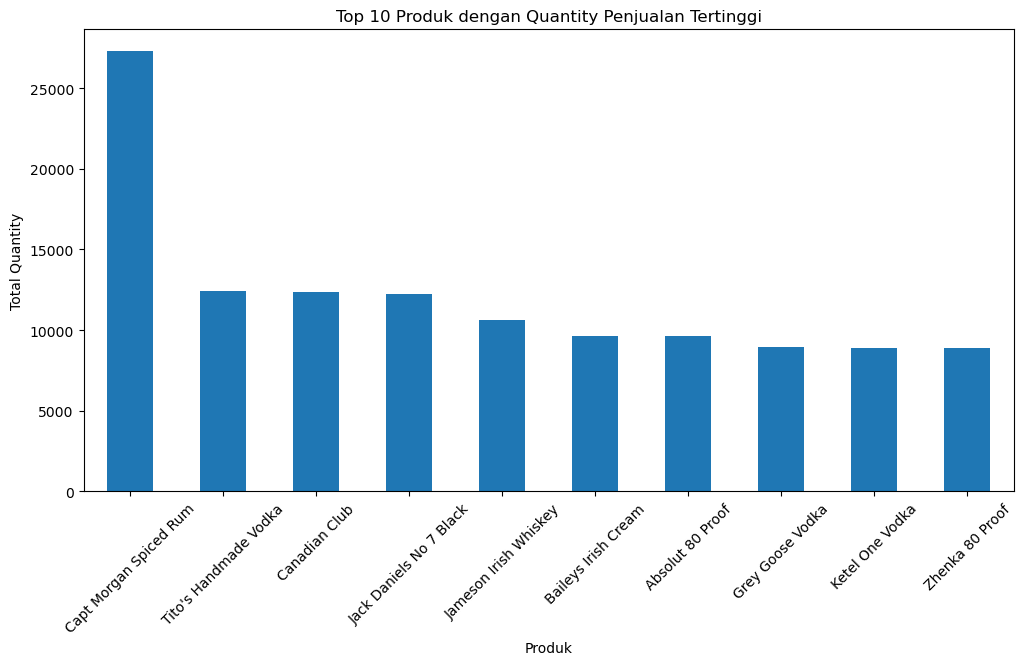

In [32]:
plt.figure(figsize=(12,6))

sales.groupby(
    'Description'
)['SalesQuantity'].sum().sort_values(
    ascending=False
).head(10).plot(
    kind='bar'
)

plt.title('Top 10 Produk dengan Quantity Penjualan Tertinggi')
plt.xlabel('Produk')
plt.ylabel('Total Quantity')

plt.xticks(rotation=45)

plt.show()

Berdasarkan visualisasi *Top 10 Produk dengan Quantity Penjualan Tertinggi*, produk **Capt Morgan Spiced Rum** menjadi produk dengan jumlah penjualan paling tinggi dibandingkan produk lainnya. Jumlah quantity produk ini terlihat jauh lebih unggul dibandingkan produk lain pada kategori top 10.

Selain itu, terdapat beberapa produk lain seperti **Tito’s Handmade Vodka**, **Canadian Club**, dan **Jack Daniel’s No 7 Black** yang juga memiliki performa penjualan cukup tinggi, namun masih berada di bawah Capt Morgan Spiced Rum.

Hal ini menunjukkan bahwa:
- Produk kategori spirit khususnya rum dan whiskey memiliki tingkat permintaan yang tinggi pada aplikasi SiDoku.
- Capt Morgan Spiced Rum kemungkinan merupakan produk favorit pelanggan karena kombinasi faktor seperti harga, popularitas merek, dan preferensi konsumen.
- Tingginya quantity penjualan dapat menjadi indikator bahwa produk tersebut memiliki perputaran stok yang cepat (*fast moving product*).

Dari sisi bisnis, perusahaan dapat:
- Menjaga ketersediaan stok produk unggulan agar tidak terjadi *stock out*.
- Menjadikan produk terlaris sebagai strategi promosi utama untuk meningkatkan transaksi.
- Mengembangkan strategi *bundling* atau rekomendasi produk serupa untuk meningkatkan nilai pembelian pelanggan.

## Pertanyaan 2:
Bagaimana tren total penjualan produk pada aplikasi SiDoku di setiap bulan selama periode penjualan berlangsung?

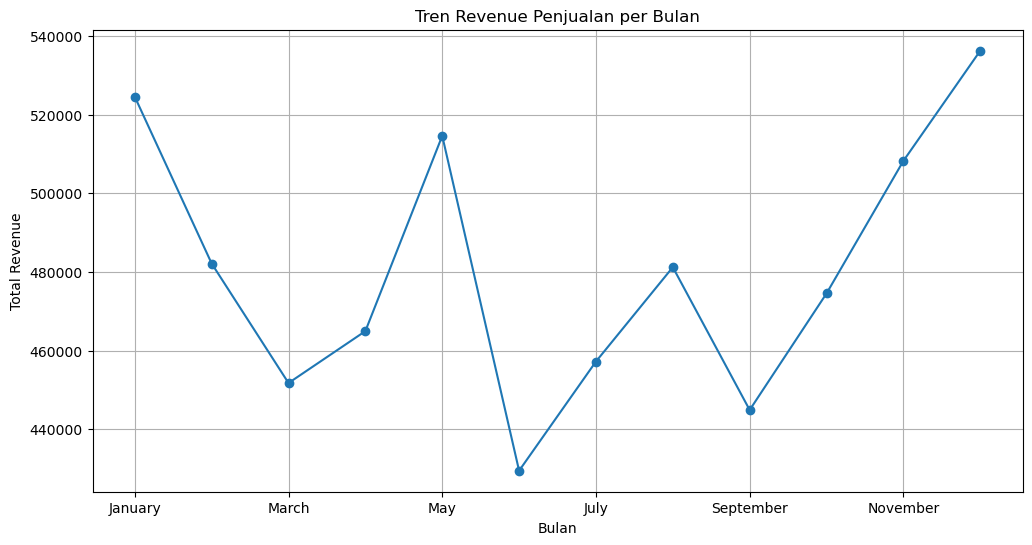

In [33]:
plt.figure(figsize=(12,6))

sales.groupby(
    'bulan_penjualan'
)['Revenue'].sum().reindex([
    'January',
    'February',
    'March',
    'April',
    'May',
    'June',
    'July',
    'August',
    'September',
    'October',
    'November',
    'December'
]).plot(
    marker='o'
)

plt.title('Tren Revenue Penjualan per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Total Revenue')

plt.grid(True)

plt.show()

Berdasarkan grafik *Tren Revenue Penjualan per Bulan*, total revenue penjualan mengalami fluktuasi selama periode transaksi berlangsung.

Beberapa temuan utama:
- Revenue tertinggi terjadi pada bulan **Desember**, diikuti oleh bulan **Januari** dan **Mei**.
- Penurunan paling signifikan terjadi pada bulan **Juni**, yang menjadi titik revenue terendah selama periode pengamatan.
- Setelah mengalami penurunan pada pertengahan tahun, revenue kembali meningkat secara bertahap hingga akhir tahun.

Pola ini mengindikasikan adanya kemungkinan:
- Pengaruh musim atau periode tertentu terhadap perilaku pembelian pelanggan.
- Peningkatan transaksi menjelang akhir tahun yang kemungkinan dipicu oleh momen liburan, perayaan, atau peningkatan aktivitas konsumsi masyarakat.
- Penurunan transaksi di pertengahan tahun dapat disebabkan oleh menurunnya daya beli atau tidak adanya momentum promosi besar.

Dari perspektif bisnis:
- Perusahaan dapat memaksimalkan strategi promosi pada periode akhir tahun karena terbukti menghasilkan revenue tinggi.
- Bulan dengan performa rendah seperti Juni dapat menjadi fokus evaluasi untuk meningkatkan penjualan melalui diskon, campaign marketing, atau loyalty program.
- Analisis tren bulanan dapat membantu proses forecasting penjualan dan pengelolaan stok secara lebih optimal.

## Pertanyaan 3:
Hari apa yang memiliki aktivitas transaksi penjualan tertinggi berdasarkan data penjualan pada aplikasi SiDoku?

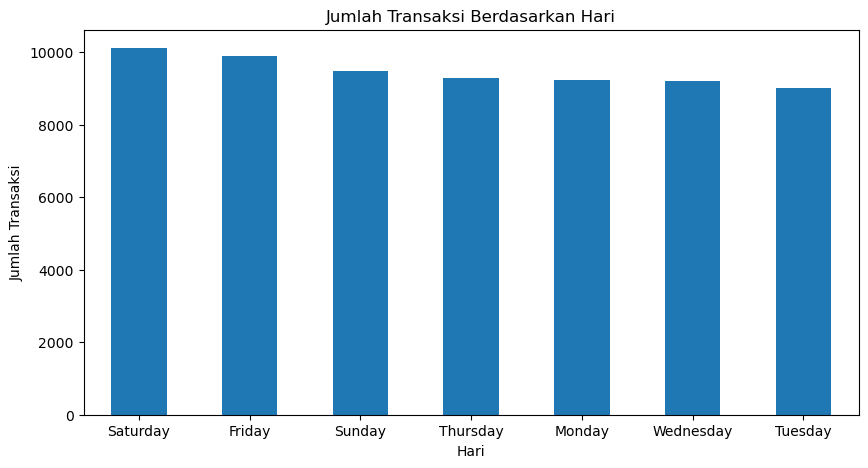

In [34]:
plt.figure(figsize=(10,5))

sales['hari_penjualan'].value_counts().plot(
    kind='bar'
)

plt.title('Jumlah Transaksi Berdasarkan Hari')
plt.xlabel('Hari')
plt.ylabel('Jumlah Transaksi')

plt.xticks(rotation=0)

plt.show()

Berdasarkan visualisasi *Jumlah Transaksi Berdasarkan Hari*, hari **Sabtu** memiliki jumlah transaksi tertinggi dibandingkan hari lainnya. Sementara itu, hari **Selasa** menjadi hari dengan jumlah transaksi paling rendah.

Temuan ini menunjukkan bahwa:
- Aktivitas transaksi cenderung meningkat pada akhir pekan (*weekend effect*).
- Pelanggan lebih aktif melakukan pembelian ketika memasuki waktu libur atau akhir pekan.
- Pola perilaku konsumen menunjukkan adanya peningkatan konsumsi pada hari Jumat hingga Minggu.

Dari sisi operasional dan bisnis:
- Perusahaan dapat meningkatkan kesiapan stok dan kapasitas layanan menjelang akhir pekan.
- Strategi promosi dapat difokuskan pada weekday untuk meningkatkan transaksi pada hari dengan performa rendah.
- Penjadwalan tenaga kerja, distribusi barang, dan pengelolaan inventory dapat disesuaikan berdasarkan pola transaksi harian agar lebih efisien.

Selain itu, pola transaksi harian ini dapat menjadi dasar dalam menentukan:
- waktu terbaik menjalankan campaign marketing,
- jadwal promo flash sale,
- serta optimasi distribusi produk pada hari dengan demand tinggi.

## Pertanyaan 4:
Produk apa yang menghasilkan total revenue terbesar pada aplikasi SiDoku selama periode transaksi berlangsung?

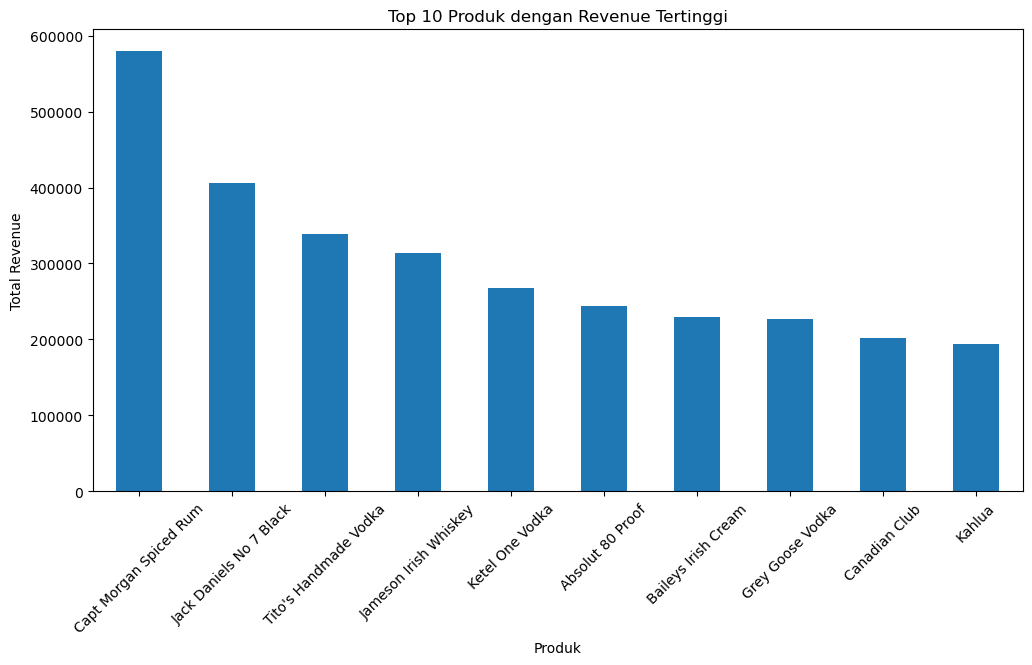

In [35]:
plt.figure(figsize=(12,6))

sales.groupby(
    'Description'
)['Revenue'].sum().sort_values(
    ascending=False
).head(10).plot(
    kind='bar'
)

plt.title('Top 10 Produk dengan Revenue Tertinggi')
plt.xlabel('Produk')
plt.ylabel('Total Revenue')

plt.xticks(rotation=45)

plt.show()

Berdasarkan grafik *Top 10 Produk dengan Revenue Tertinggi*, produk **Capt Morgan Spiced Rum** menghasilkan total revenue terbesar dibandingkan seluruh produk lainnya.

Produk lain seperti:
- **Jack Daniel’s No 7 Black**
- **Tito’s Handmade Vodka**
- **Jameson Irish Whiskey**

juga memberikan kontribusi revenue yang cukup besar, namun masih berada di bawah Capt Morgan Spiced Rum.

Temuan ini menunjukkan bahwa:
- Produk unggulan tidak hanya memiliki quantity penjualan tinggi, tetapi juga memberikan kontribusi pendapatan terbesar bagi perusahaan.
- Produk dengan brand kuat dan permintaan stabil memiliki pengaruh signifikan terhadap total revenue bisnis.
- Revenue tinggi dapat berasal dari kombinasi volume penjualan tinggi dan harga jual produk yang relatif lebih besar.

Implikasi bisnis dari hasil ini:
- Produk dengan kontribusi revenue terbesar perlu menjadi prioritas dalam strategi inventory dan pemasaran.
- Perusahaan dapat mempertimbangkan strategi cross-selling untuk meningkatkan pembelian produk premium lainnya.
- Analisis revenue produk membantu perusahaan dalam menentukan produk prioritas untuk promosi, distribusi, dan pengembangan pasar.

Selain itu, perusahaan juga perlu menjaga loyalitas pelanggan terhadap produk unggulan karena ketergantungan revenue yang tinggi pada produk tertentu dapat menjadi risiko apabila terjadi penurunan permintaan.

## Pertanyaan 5:
Bagaimana distribusi harga penjualan produk berdasarkan data transaksi pada aplikasi SiDoku?

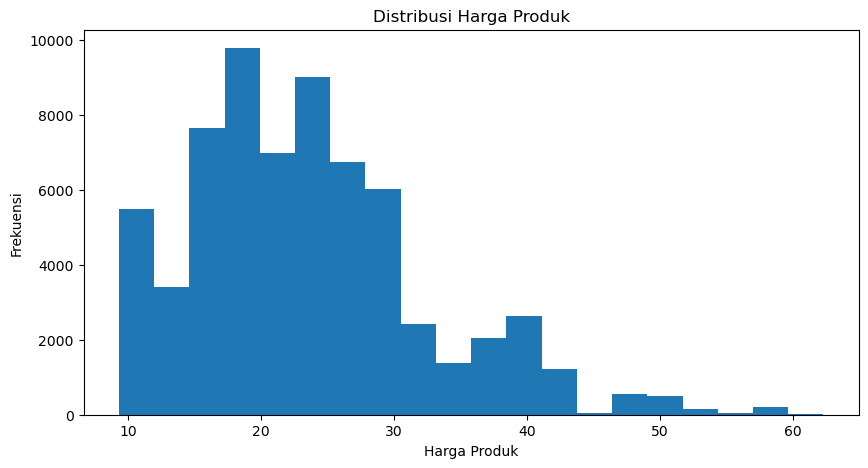

In [36]:
plt.figure(figsize=(10,5))

plt.hist(
    sales['SalesPrice'],
    bins=20
)

plt.title('Distribusi Harga Produk')
plt.xlabel('Harga Produk')
plt.ylabel('Frekuensi')

plt.show()

Berdasarkan histogram distribusi harga produk, sebagian besar transaksi berada pada rentang harga sekitar **15 hingga 30**. Distribusi data terlihat **miring ke kanan (*right skewed*)**, yang menunjukkan bahwa produk dengan harga rendah hingga menengah lebih mendominasi transaksi dibandingkan produk dengan harga premium.

Temuan utama:
- Mayoritas pelanggan cenderung membeli produk dengan harga yang lebih terjangkau.
- Jumlah produk dengan harga tinggi relatif lebih sedikit dan frekuensi transaksinya juga lebih rendah.
- Terdapat beberapa produk premium dengan harga di atas 50, namun kontribusinya terhadap jumlah transaksi tidak sebesar produk harga menengah.

Hal ini mengindikasikan bahwa:
- Sensitivitas pelanggan terhadap harga cukup tinggi.
- Pasar utama aplikasi SiDoku kemungkinan berada pada segmen konsumen menengah.
- Produk harga menengah menjadi penggerak utama volume transaksi.

Dari perspektif bisnis:
- Strategi penjualan dapat difokuskan pada produk dengan harga menengah karena memiliki demand paling tinggi.
- Produk premium tetap penting untuk meningkatkan margin keuntungan meskipun jumlah transaksinya lebih sedikit.
- Perusahaan dapat menerapkan strategi segmentasi produk berdasarkan kategori harga untuk menjangkau berbagai tipe pelanggan.

Selain itu, distribusi harga ini juga dapat dimanfaatkan untuk:
- menentukan strategi pricing,
- membuat paket bundling produk,
- serta mengembangkan rekomendasi produk berdasarkan preferensi harga pelanggan.

## Pertanyaan 6:

 Apakah transaksi pada hari kerja (weekday) lebih tinggi dibandingkan akhir pekan (weekend) berdasarkan data transaksi aplikasi SiDoku?

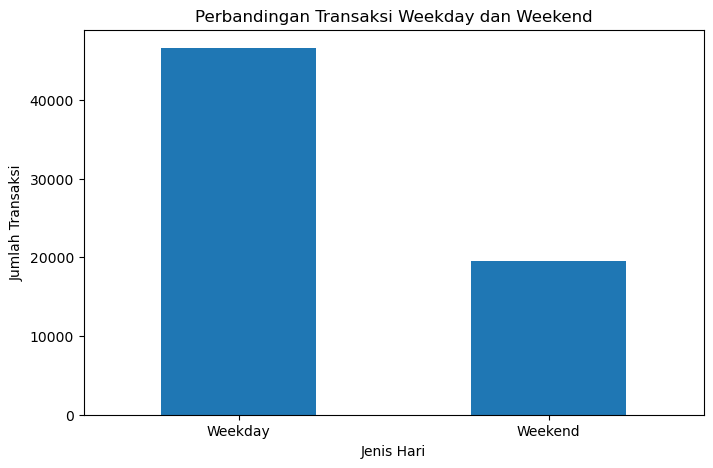

In [37]:
plt.figure(figsize=(8,5))

sales['jenis_hari'].value_counts().plot(
    kind='bar'
)

plt.title('Perbandingan Transaksi Weekday dan Weekend')
plt.xlabel('Jenis Hari')
plt.ylabel('Jumlah Transaksi')

plt.xticks(rotation=0)

plt.show()

Berdasarkan visualisasi perbandingan transaksi weekday dan weekend, jumlah transaksi pada kategori Weekday terlihat lebih tinggi dibandingkan Weekend.

Namun, hal ini dipengaruhi oleh jumlah hari weekday yang lebih banyak dibandingkan weekend dalam satu minggu.

Meskipun demikian, transaksi pada weekend tetap menunjukkan aktivitas yang cukup tinggi dan mengindikasikan bahwa pelanggan cenderung lebih aktif melakukan pembelian pada waktu libur.

Temuan ini menunjukkan bahwa:

- Aktivitas transaksi pelanggan tetap stabil sepanjang minggu.
- Weekend menjadi periode potensial untuk meningkatkan penjualan melalui campaign khusus.
- Pola transaksi berdasarkan waktu dapat dimanfaatkan untuk strategi pemasaran yang lebih efektif.

Dari sisi bisnis:

- Perusahaan dapat menjalankan promo khusus akhir pekan untuk meningkatkan transaksi.
- Strategi digital marketing dapat difokuskan pada waktu dengan aktivitas pelanggan tertinggi.
- Pengelolaan stok dan operasional dapat disesuaikan berdasarkan pola transaksi pelanggan.

Selain itu, analisis weekday dan weekend juga membantu perusahaan memahami perilaku pelanggan berdasarkan waktu transaksi sehingga strategi bisnis dapat dijalankan secara lebih optimal.

## Pertanyaan 7:

Kategori harga produk apa yang paling mendominasi transaksi penjualan pada aplikasi SiDoku?

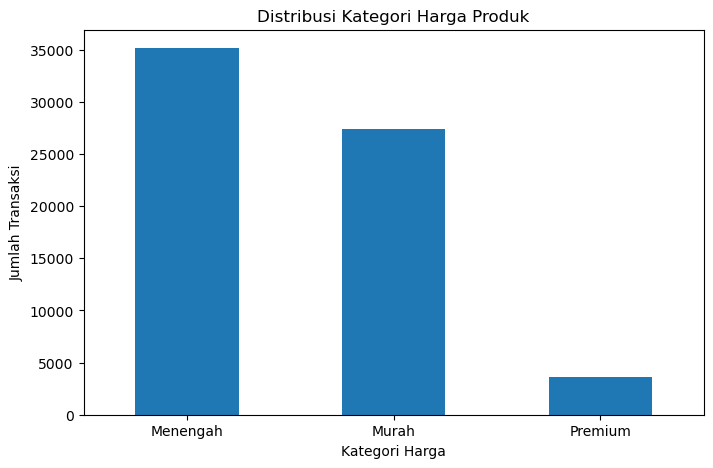

In [38]:
plt.figure(figsize=(8,5))

sales['kategori_harga'].value_counts().plot(
    kind='bar'
)

plt.title('Distribusi Kategori Harga Produk')
plt.xlabel('Kategori Harga')
plt.ylabel('Jumlah Transaksi')

plt.xticks(rotation=0)

plt.show()

Berdasarkan visualisasi distribusi kategori harga produk, kategori Menengah menjadi kategori dengan jumlah transaksi paling tinggi dibandingkan kategori lainnya.

Hal ini menunjukkan bahwa mayoritas pelanggan pada aplikasi SiDoku cenderung membeli produk dengan harga yang masih terjangkau namun tetap memiliki kualitas yang baik.

Sementara itu, kategori Premium memiliki jumlah transaksi yang lebih rendah dibandingkan kategori lainnya karena segmentasi pasarnya lebih spesifik.

Temuan ini mengindikasikan bahwa:

- Produk kategori menengah merupakan target pasar utama pada aplikasi SiDoku.
- Pelanggan memiliki kecenderungan memilih produk dengan harga yang seimbang antara kualitas dan harga.
- Produk premium tetap memiliki potensi revenue tinggi meskipun volume transaksinya lebih kecil.

Dari perspektif bisnis:

- Perusahaan dapat memprioritaskan produk kategori menengah sebagai fokus utama penjualan.
- Produk premium dapat digunakan sebagai strategi peningkatan profit margin.
- Strategi pricing dan promosi dapat disesuaikan berdasarkan kategori harga produk.

Selain itu, segmentasi kategori harga membantu perusahaan dalam memahami pola konsumsi pelanggan dan mendukung pengambilan keputusan bisnis yang lebih tepat sasaran.

# Advanced Analysis

Advanced analysis dilakukan untuk memperoleh insight yang lebih mendalam terkait pola transaksi, hubungan antar variabel, segmentasi pelanggan, serta tren penjualan pada aplikasi SiDoku.

In [39]:
bulan_order = [
    'January','February','March','April',
    'May','June','July','August',
    'September','October','November','December'
]

## Correlation Analysis

Correlation analysis dilakukan untuk mengetahui hubungan antar variabel numerik pada dataset penjualan, seperti harga produk, jumlah penjualan, dan revenue.

In [40]:
sales[['SalesPrice','SalesQuantity','Revenue']].corr()

,SalesPrice,SalesQuantity,Revenue
SalesPrice,1.000000,-0.109423,0.130715
SalesQuantity,-0.109423,1.000000,0.923369
Revenue,0.130715,0.923369,1.000000


### Insight

Berdasarkan hasil correlation analysis, variabel Revenue memiliki hubungan korelasi positif yang sangat kuat dengan SalesQuantity dengan nilai korelasi sekitar 0.92.

Hal ini menunjukkan bahwa peningkatan jumlah produk yang terjual memiliki pengaruh besar terhadap peningkatan revenue perusahaan.

Sementara itu, SalesPrice memiliki hubungan korelasi positif yang relatif lemah terhadap Revenue. Temuan ini mengindikasikan bahwa jumlah produk yang terjual lebih berpengaruh terhadap total pendapatan dibandingkan kenaikan harga produk.

Selain itu, hubungan negatif kecil antara SalesPrice dan SalesQuantity menunjukkan bahwa produk dengan harga lebih tinggi cenderung memiliki jumlah penjualan yang sedikit lebih rendah.

Dari perspektif bisnis:
- Peningkatan volume penjualan menjadi faktor utama dalam meningkatkan revenue.
- Strategi promosi untuk meningkatkan quantity penjualan dapat memberikan dampak signifikan terhadap pendapatan perusahaan.
- Perusahaan dapat mempertimbangkan kombinasi strategi pricing dan peningkatan demand untuk mengoptimalkan revenue.

Analisis korelasi membantu perusahaan memahami hubungan antar variabel penting sehingga pengambilan keputusan bisnis dapat dilakukan secara lebih efektif dan berbasis data.

## Heatmap Correlation

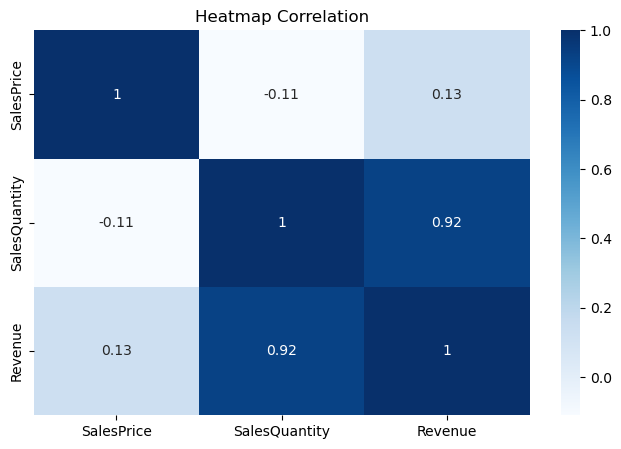

In [41]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.heatmap(
    sales[['SalesPrice','SalesQuantity','Revenue']].corr(),
    annot=True,
    cmap='Blues'
)

plt.title('Heatmap Correlation')

plt.show()

### Insight

Visualisasi heatmap correlation memperjelas hubungan antar variabel numerik pada dataset penjualan.

Semakin gelap warna pada heatmap menunjukkan tingkat korelasi yang semakin kuat antar variabel.

Berdasarkan heatmap:
- Revenue dan SalesQuantity memiliki hubungan paling kuat dengan nilai korelasi tinggi.
- SalesPrice memiliki hubungan positif namun tidak terlalu signifikan terhadap Revenue.
- Tidak ditemukan korelasi negatif yang kuat antar variabel utama.

Temuan ini menunjukkan bahwa performa revenue perusahaan lebih dipengaruhi oleh jumlah transaksi penjualan dibandingkan kenaikan harga produk.

Dari sisi bisnis:
- Fokus peningkatan penjualan produk dapat menjadi strategi utama untuk meningkatkan pendapatan.
- Perusahaan dapat menjaga stabilitas harga sambil meningkatkan volume transaksi melalui promosi dan campaign pemasaran.
- Heatmap membantu proses identifikasi pola hubungan data secara visual sehingga mempermudah proses analisis bisnis.

## Customer Segmentation Sederhana

Segmentasi pelanggan sederhana dilakukan berdasarkan total revenue transaksi untuk mengelompokkan pelanggan dengan kontribusi pembelian yang berbeda.

In [42]:
sales['customer_segment'] = pd.cut(
    sales['Revenue'],
    bins=[0,50,100,1000],
    labels=['Low','Medium','High']
)

sales[['Revenue','customer_segment']].head()

,Revenue,customer_segment
0,19.98,Low
1,59.98,Medium
2,78.40,Medium
3,38.97,Low
4,38.99,Low


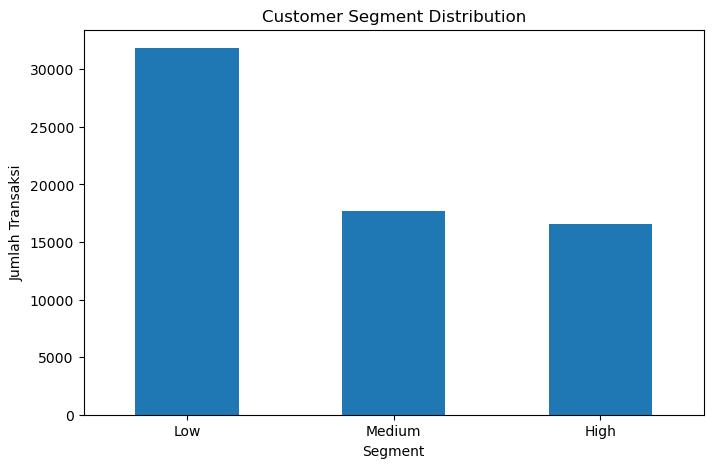

In [43]:
plt.figure(figsize=(8,5))

sales['customer_segment'].value_counts().plot(
    kind='bar'
)

plt.title('Customer Segment Distribution')
plt.xlabel('Segment')
plt.ylabel('Jumlah Transaksi')

plt.xticks(rotation=0)

plt.show()

### Insight

Berdasarkan hasil customer segmentation sederhana, kategori pelanggan Low mendominasi jumlah transaksi dibandingkan kategori Medium dan High.

Hal ini menunjukkan bahwa sebagian besar pelanggan melakukan transaksi dengan nilai pembelian relatif kecil hingga menengah.

Meskipun jumlah pelanggan kategori High lebih sedikit, kelompok ini tetap memiliki kontribusi revenue yang cukup besar terhadap perusahaan.

Temuan ini mengindikasikan bahwa:
- Aplikasi SiDoku memiliki basis pelanggan utama pada segmen pembelian menengah ke bawah.
- Pelanggan kategori High berpotensi menjadi pelanggan loyal dengan nilai transaksi lebih besar.
- Segmentasi pelanggan membantu perusahaan memahami karakteristik transaksi pelanggan secara lebih spesifik.

Dari perspektif bisnis:
- Perusahaan dapat membuat strategi promosi yang berbeda untuk setiap segmen pelanggan.
- Pelanggan kategori High dapat dijadikan target loyalty program atau promo eksklusif.
- Segmentasi pelanggan membantu meningkatkan efektivitas strategi pemasaran dan personalisasi layanan.

Dengan memahami karakteristik tiap segmen pelanggan, perusahaan dapat meningkatkan customer retention dan optimalisasi revenue bisnis.

## Monthly Revenue Growth

In [44]:
monthly_growth = sales.groupby(
    'bulan_penjualan'
)['Revenue'].sum().pct_change() * 100

monthly_growth

bulan_penjualan
April              NaN
August        3.500863
December     11.451194
February    -10.100869
January       8.803462
July        -12.847207
June         -6.080380
March         5.199000
May          13.929383
November     -1.237740
October      -6.638830
September    -6.252448
Name: Revenue, dtype: float64

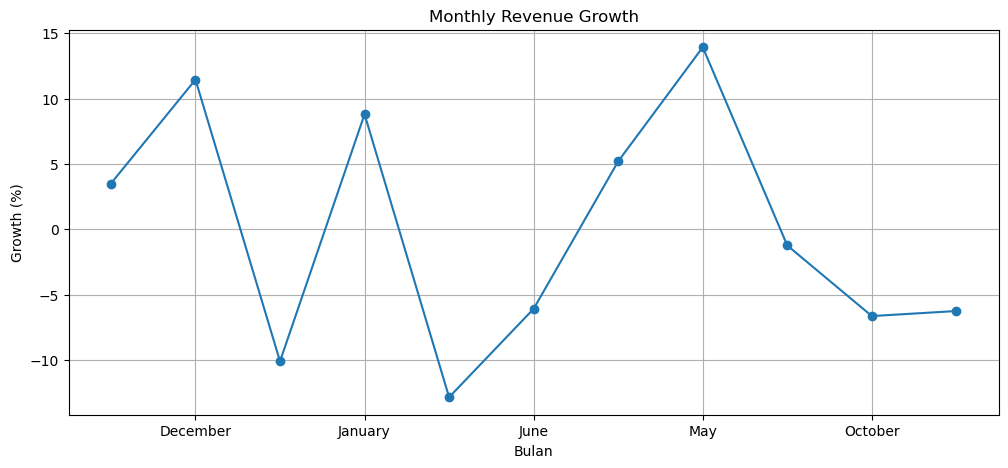

In [45]:
plt.figure(figsize=(12,5))

monthly_growth.plot(
    marker='o'
)

plt.title('Monthly Revenue Growth')
plt.xlabel('Bulan')
plt.ylabel('Growth (%)')

plt.grid(True)

plt.show()

### Insight

Analisis monthly revenue growth menunjukkan bahwa pertumbuhan revenue mengalami fluktuasi selama periode penjualan berlangsung.

Beberapa bulan mengalami pertumbuhan positif yang cukup tinggi, sementara bulan lainnya mengalami penurunan revenue.

Pertumbuhan revenue tertinggi terlihat terjadi pada periode tertentu seperti bulan Mei dan Desember, yang menunjukkan adanya peningkatan aktivitas transaksi pada periode tersebut.

Sebaliknya, beberapa bulan mengalami penurunan pertumbuhan yang mengindikasikan adanya penurunan aktivitas pembelian pelanggan.

Temuan ini menunjukkan bahwa:
- Performa penjualan bersifat dinamis dan dipengaruhi oleh waktu tertentu.
- Terdapat indikasi pola musiman pada aktivitas transaksi pelanggan.
- Revenue perusahaan tidak selalu stabil setiap bulan.

Dari sisi bisnis:
- Perusahaan dapat memanfaatkan periode dengan growth tinggi untuk memaksimalkan strategi penjualan.
- Bulan dengan pertumbuhan negatif dapat dijadikan bahan evaluasi strategi pemasaran.
- Analisis growth membantu proses forecasting dan pengambilan keputusan bisnis secara lebih strategis.

## Top dan Bottom Product

In [46]:
top_product = sales.groupby(
    'Description'
)['Revenue'].sum().sort_values(
    ascending=False
).head(5)

bottom_product = sales.groupby(
    'Description'
)['Revenue'].sum().sort_values(
    ascending=True
).head(5)

print(top_product)

print(bottom_product)

Description
Capt Morgan Spiced Rum     579221.16
Jack Daniels No 7 Black    405527.21
Tito's Handmade Vodka      339037.56
Jameson Irish Whiskey      313794.96
Ketel One Vodka            268346.77
Name: Revenue, dtype: float64
Description
Simi Chard                 23422.92
Clos du Bois Chard         25962.30
Svedka Vodka               40841.28
J Lohr Riverstone Chard    41153.37
Bombay Sapphire Gin        43068.03
Name: Revenue, dtype: float64


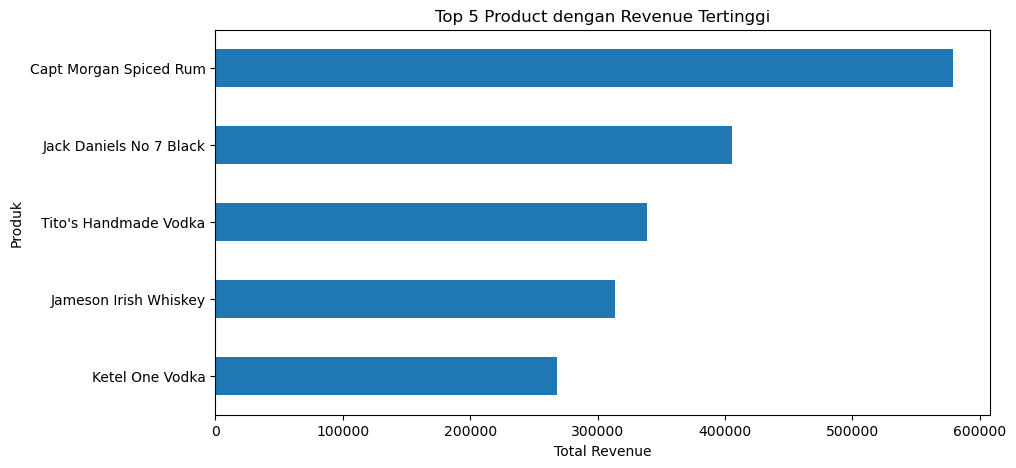

In [47]:
top_product = sales.groupby(
    'Description'
)['Revenue'].sum().sort_values(
    ascending=False
).head(5)

plt.figure(figsize=(10,5))

top_product.sort_values().plot(
    kind='barh'
)

plt.title('Top 5 Product dengan Revenue Tertinggi')
plt.xlabel('Total Revenue')
plt.ylabel('Produk')

plt.show()

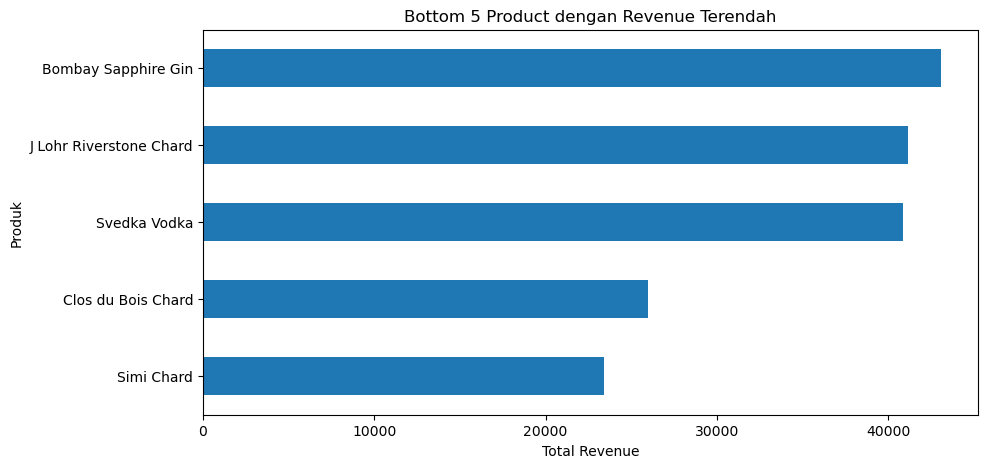

In [48]:
bottom_product = sales.groupby(
    'Description'
)['Revenue'].sum().sort_values(
    ascending=True
).head(5)

plt.figure(figsize=(10,5))

bottom_product.plot(
    kind='barh'
)

plt.title('Bottom 5 Product dengan Revenue Terendah')
plt.xlabel('Total Revenue')
plt.ylabel('Produk')

plt.show()

### Insight

Analisis top dan bottom product menunjukkan adanya perbedaan kontribusi revenue yang cukup signifikan antar produk.

Produk seperti Capt Morgan Spiced Rum, Jack Daniels No 7 Black, dan Tito's Handmade Vodka menjadi produk dengan kontribusi revenue tertinggi pada aplikasi SiDoku.

Hal ini menunjukkan bahwa produk-produk tersebut memiliki tingkat permintaan yang tinggi dan menjadi produk unggulan perusahaan.

Sementara itu, beberapa produk pada kategori bottom product memiliki kontribusi revenue yang relatif rendah dibandingkan produk lainnya.

Temuan ini mengindikasikan bahwa:
- Tidak semua produk memiliki performa penjualan yang sama.
- Produk unggulan memberikan kontribusi besar terhadap total revenue perusahaan.
- Produk dengan revenue rendah perlu dievaluasi lebih lanjut terkait strategi penjualan dan pengelolaan inventory.

Dari perspektif bisnis:
- Produk top performing perlu diprioritaskan dalam strategi promosi dan pengelolaan stok.
- Produk bottom performing dapat diberikan strategi diskon atau bundling untuk meningkatkan penjualan.
- Analisis performa produk membantu perusahaan menentukan prioritas pengembangan bisnis secara lebih optimal.

## Outlier Detection

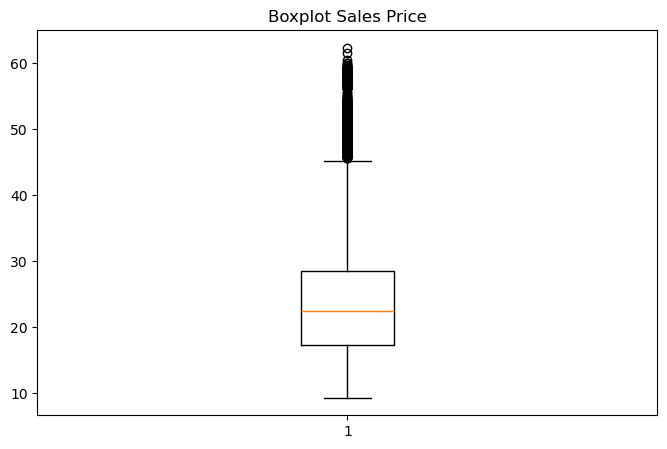

In [49]:
plt.figure(figsize=(8,5))

plt.boxplot(sales['SalesPrice'])

plt.title('Boxplot Sales Price')

plt.show()

### Insight

Berdasarkan visualisasi boxplot SalesPrice, terlihat terdapat sejumlah outlier pada data harga produk.

Outlier tersebut menunjukkan adanya beberapa produk dengan harga yang jauh lebih tinggi dibandingkan mayoritas produk lainnya.

Mayoritas produk berada pada rentang harga menengah, sementara produk premium dengan harga tinggi muncul sebagai titik outlier pada visualisasi.

Temuan ini mengindikasikan bahwa:
- Dataset memiliki variasi harga produk yang cukup besar.
- Produk premium tetap menjadi bagian penting dalam penjualan meskipun jumlahnya lebih sedikit.
- Distribusi harga produk tidak sepenuhnya merata.

Dari sisi bisnis:
- Produk dengan harga tinggi dapat menjadi sumber margin keuntungan yang lebih besar.
- Analisis outlier membantu perusahaan memahami karakteristik produk premium.
- Deteksi outlier juga penting untuk memastikan tidak terdapat kesalahan input data pada proses transaksi.

Dengan memahami pola outlier harga produk, perusahaan dapat melakukan evaluasi pricing strategy secara lebih tepat.

## Forecasting Sederhana

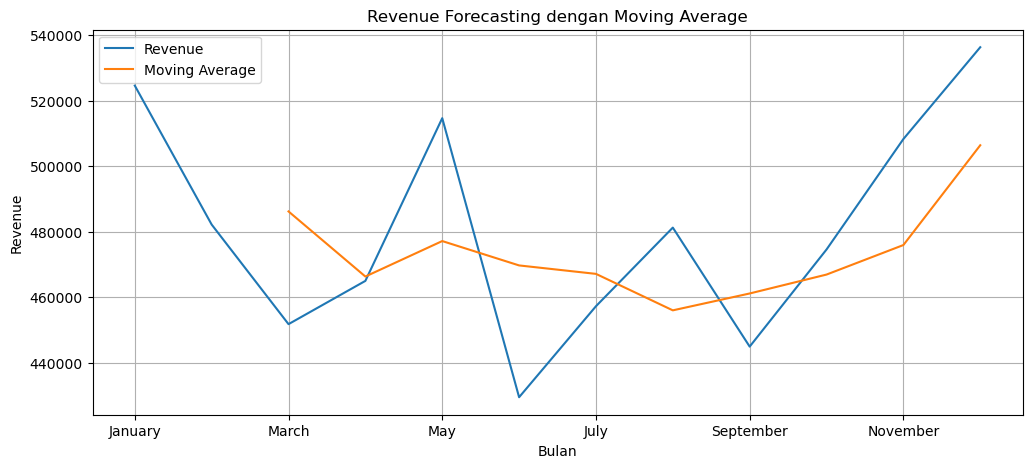

In [50]:
monthly_revenue = sales.groupby(
    'bulan_penjualan'
)['Revenue'].sum().reindex(bulan_order)

moving_avg = monthly_revenue.rolling(
    window=3
).mean()

plt.figure(figsize=(12,5))

monthly_revenue.plot(
    label='Revenue'
)

moving_avg.plot(
    label='Moving Average'
)

plt.title('Revenue Forecasting dengan Moving Average')
plt.xlabel('Bulan')
plt.ylabel('Revenue')

plt.legend()

plt.grid(True)

plt.show()

### Insight

Forecasting sederhana menggunakan metode moving average menunjukkan pola tren revenue yang cenderung mengalami fluktuasi selama periode penjualan berlangsung.

Garis moving average membantu memperhalus perubahan revenue sehingga tren penjualan menjadi lebih mudah dianalisis dibandingkan hanya melihat data revenue asli.

Berdasarkan visualisasi:
- Revenue mengalami kenaikan pada beberapa periode tertentu, terutama menjelang akhir tahun.
- Terdapat penurunan revenue pada pertengahan tahun sebelum kembali mengalami peningkatan.
- Moving average menunjukkan kecenderungan tren revenue yang relatif stabil dalam jangka panjang.

Temuan ini mengindikasikan bahwa:
- Aktivitas penjualan memiliki pola musiman tertentu.
- Revenue perusahaan dipengaruhi oleh periode transaksi pelanggan.
- Tren penjualan dapat diprediksi menggunakan pendekatan time series sederhana.

Dari perspektif bisnis:
- Forecasting membantu perusahaan dalam proses perencanaan stok dan strategi penjualan.
- Perusahaan dapat mempersiapkan promosi pada periode dengan potensi peningkatan revenue.
- Analisis tren membantu pengambilan keputusan bisnis secara lebih proaktif dan berbasis data.

Forecasting sederhana menjadi langkah awal yang penting dalam memahami pola pertumbuhan bisnis dan mendukung pengembangan analisis prediktif di masa mendatang.

# Conclusion

Berdasarkan hasil analisis data penjualan pada aplikasi SiDoku, diperoleh berbagai insight penting terkait performa produk, perilaku pelanggan, serta tren penjualan selama periode transaksi berlangsung.

Hasil analisis menunjukkan bahwa produk Capt Morgan Spiced Rum menjadi produk dengan quantity penjualan dan revenue tertinggi dibandingkan produk lainnya. Temuan ini mengindikasikan bahwa produk tersebut memiliki tingkat permintaan yang sangat tinggi dan menjadi salah satu produk unggulan pada aplikasi SiDoku.

Analisis tren revenue bulanan menunjukkan bahwa penjualan mengalami fluktuasi selama periode transaksi berlangsung. Revenue tertinggi terjadi pada beberapa periode tertentu seperti akhir tahun, sedangkan beberapa bulan lainnya mengalami penurunan pertumbuhan revenue. Hal ini menunjukkan adanya pola musiman (seasonality) pada aktivitas transaksi pelanggan.

Berdasarkan analisis hari transaksi, aktivitas penjualan cenderung lebih tinggi pada akhir pekan, khususnya hari Sabtu. Temuan ini menunjukkan bahwa pelanggan lebih aktif melakukan pembelian pada waktu libur dibandingkan hari kerja biasa.

Selain itu, distribusi harga produk menunjukkan bahwa mayoritas transaksi berada pada kategori harga menengah. Hal ini mengindikasikan bahwa pelanggan cenderung memilih produk dengan harga yang masih terjangkau namun tetap memiliki kualitas yang baik.

Feature engineering yang dilakukan pada dataset berhasil membantu memperkaya proses analisis melalui pembuatan fitur baru seperti kategori harga produk, jenis hari transaksi, quarter penjualan, revenue, serta klasifikasi fast moving product.

Advanced analysis juga menunjukkan bahwa SalesQuantity memiliki hubungan korelasi paling kuat terhadap Revenue dibandingkan variabel lainnya. Hal ini menandakan bahwa peningkatan jumlah produk terjual menjadi faktor utama dalam meningkatkan pendapatan perusahaan.

Customer segmentation sederhana menunjukkan bahwa mayoritas pelanggan berada pada kategori transaksi Low hingga Medium, sedangkan pelanggan kategori High memiliki kontribusi revenue yang cukup besar meskipun jumlahnya lebih sedikit.

Forecasting sederhana menggunakan metode moving average menunjukkan bahwa tren revenue perusahaan cenderung mengalami fluktuasi namun tetap memiliki pola pertumbuhan yang relatif stabil dalam jangka panjang.

Secara keseluruhan, hasil analisis ini dapat membantu perusahaan dalam:
- menentukan strategi promosi yang lebih efektif,
- memahami perilaku pelanggan,
- mengoptimalkan pengelolaan inventory,
- melakukan forecasting penjualan,
- meningkatkan strategi pricing,
- serta mendukung pengambilan keputusan bisnis berbasis data.

Dengan memanfaatkan hasil analisis ini, aplikasi SiDoku diharapkan mampu meningkatkan efektivitas strategi bisnis dan mendorong pertumbuhan revenue perusahaan secara lebih optimal di masa mendatang.